# Novo Ensino Suplementar (NES)
## Inteligência Artificial e Banco de Dados
### Aula 4- Classficadores - KNN
#### Dr. Leonardo Medeiros


# **Primeira Aplicacao com IA**
Agora, iremos criar uma simples aplicacao utilizando aprendizagem de maquina por meio da criacao de um modelo preditivo.

Vamos assumir que um botˆanico est´a interessado em distinguir uma especie diferente de L´ırio (do inglˆes. iris) que ele encontrou em seu jardim. Este botˆanico coletou algumas medidas associadas a especie como: comprimento e largura das petalas, e o comprimento e largura da s´epala (do inglˆes. sepal) tudo mensurado em centimetros.

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.keys())
print(iris['DESCR'][:193] + "\n...")



dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive 
...


#### Conteúdo dos Dados

In [3]:
#Vetores de Características
from sklearn.datasets import load_iris
iris = load_iris()
print(iris['target_names'])


['setosa' 'versicolor' 'virginica']


### Valores das Características

In [4]:
from sklearn.datasets import load_iris
iris = load_iris()
print(type(iris['data']))
print(iris['data'])

<class 'numpy.ndarray'>
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3

Classe Real dos Dados (Label)
A matriz objetivo (target) armazena um identificador (label) da classe a qual aquele dado pertence. Como tipo de dados ela se mantem como uma array numpy.

In [5]:
from sklearn.datasets import load_iris
iris = load_iris()
type(iris['target'])
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

O significado dos Labels ´e dado pela matriz iris [’target names’]: 0 significa Setosa, 1 significa Versicolor e 2 significa Virginica.

## Classificador KNN

In [ ]:
#Classificador KNN - PARTE 1
import numpy as np
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
iris_datasset = datasets.load_iris()
iris_X = iris_datasset.data
iris_y = iris_datasset.target
print("Iris Label Values")
print(np.unique(iris_y))
# Split iris data in train and test data
# A random permutation, to split the data randomly
np.random.seed(0)
indices = np.random.permutation(len(iris_X))
print("indices")
print(indices)

In [42]:
np.random.seed(10)
indices = np.random.permutation(100)
print(indices)

[19 14 43 37 66  3 79 41 38 68  2  1 60 53 95 74 92 26 59 46 90 70 50 44
 76 55 21 61  6 63 42 34 84 52 35 39 45  4  5 48 32 20 83 58 47 80 17 67
 81  7 87 97 98 99 24 10 96 86 56 71 23 22 91 94 18 27 88 57 31 65 12 82
 30 75 25 13 69 77 85 51 49 78 72 33 62 54 11 16 36 40  0 73  8 29 93 89
 28 64 15  9]


In [49]:
#PARTE1
import numpy as np
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
iris_datasset = datasets.load_iris()
iris_X = iris_datasset.data
iris_y = iris_datasset.target
print("Iris Label Values")
print(np.unique(iris_y))
# Split iris data in train and test data
# A random permutation, to split the data randomly
np.random.seed(500)
indices = np.random.permutation(len(iris_X))
print("indices")
print(indices)
#PARTE2
iris_X_train = iris_X[indices[:-10]]
iris_y_train = iris_y[indices[:-10]]
iris_X_test  = iris_X[indices[-10:]]
iris_y_test  = iris_y[indices[-10:]]
print("test labels")
print(iris_y_test)
# Create and fit a nearest-neighbor classifier
knn = KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')
knn.fit(iris_X_train, iris_y_train) 
predictedclasses = knn.predict(iris_X_test)
print("Predicted Instances")
print(predictedclasses)
print("Iris Label Values")
print(iris_y_test)
classifier_accuracy = np.mean(predictedclasses == iris_y_test)
print("Classifier Accuracy")
print(classifier_accuracy)


Iris Label Values
[0 1 2]
indices
[  7 126 136 133  66  99  93  85 144  16  76  84 132  36 112  78 141  82
  95  26  47  39  68  10 140 137   9  74 124   5   1 108  61 117  64 111
 107  25  48   6  50 122  49  13  40 135 119 139 148  24 113 120  83 149
  27  12  94  51 116   8  58   3 143  54  35  21  55  79  42 142 101 146
 100  88  44 103  22  32 138  19 127  86  14 110 121   0  23  11 128  63
  45 106 145  33  38 105  53  52  30  92 129 123   4  81  20  96  70  67
 130  97  43  80  37  57  69 131 115 118  15 114  98  89  87  73  28  29
  91  62  75  60 134 125  59   2 109  46  56 104 102  18  34  41 147  77
  71  72  31  17  65  90]
test labels
[0 0 2 1 1 1 0 0 1 1]
Predicted Instances
[0 0 2 1 1 2 0 0 1 1]
Iris Label Values
[0 0 2 1 1 1 0 0 1 1]
Classifier Accuracy
0.9


## Plotar os dados

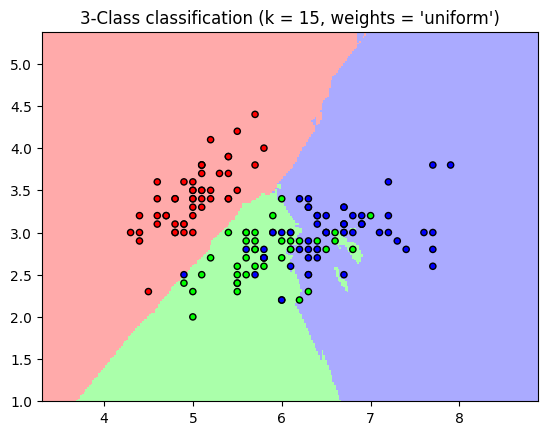

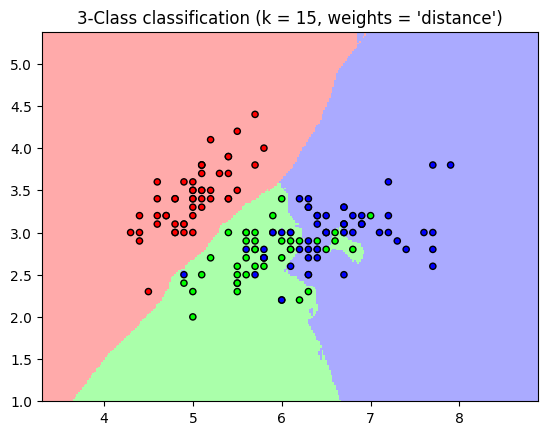

In [50]:
import numpy as np
import matplotlib.pyplot as plot
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
n_neighbors = 15
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target
h = .02  # step sipredictede in the mesh
# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
for weights in ['uniform', 'distance']:
    clf = neighbors.KNeighborsClassifier(n_neighbors, weights=weights)
    clf.fit(X, y)
    # Plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    predicted = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Put the result into a color plot
    predicted = predicted.reshape(xx.shape)
    plot.figure()
    plot.pcolormesh(xx, yy, predicted, cmap=cmap_light)
    # Plot also the training points
    plot.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
                edgecolor='k', s=20)
    plot.xlim(xx.min(), xx.max())
    plot.ylim(yy.min(), yy.max())
    plot.title("3-Class classification (k = %i, weights = '%s')"
              % (n_neighbors, weights))
    #plot.savefig("../img/plot-knn-%s.jpg"%weights)
plot.show()

# Score de Classificação

In [51]:
# Score de Classificação
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import svm 
import numpy as np
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'],
 random_state=0)
C = 1.0  # SVM regularization parameter
# SVC with linear kernel
svc = svm.SVC(kernel='linear', C=C).fit(X_train, y_train)
y_pred = svc.predict(X_test)
print(y_pred)
print(y_test)
classifier_score = np.mean(y_pred == y_test)
print(classifier_score)

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1]
0.9736842105263158


# **Avaliando o Modelo Preditivo**
Como descrito no objetivo da nossa aplicacao, queremos construir um modelo de aprendizagem de m´aquina a partir dos dados de caracteristicas de especies de lirios. Conforme descrito anteriormente, estes dados cont´em um conjunto de medidas dos lirios e ser˜ao testados novas informacoes para que o modelo
preditivo possa predizer qual a especie do lirio dos dados de teste.

Para avaliar o desempenho do modelo, dividiremos os dados e suas respectivas classes (labels). Normalmente, isso e feito em dois conjuntos de dados. A parte dos dados que e usada para construir nosso modelo de aprendizado de m´aquina ´e chamada de dados de treinamento (trainning data) ou conjunto de treinamento. O resto dos dados sera usado para acessar a acuracia do modelo por meio
dos dados de teste, conjunto de teste (test data).


O Scikit-learn contem uma funcao que mistura o conjunto de dados e os divide para você, a funcao train test split.

**Dividindo os Dados**
A funcao train_test_split pode extrair 75% das linhas nos dados como o conjunto de treinamento, juntamente com os r´otulos correspondentes para esses dados. Os 25% restantes dos dados, juntamente com os restantes rótulos s˜ao declarados como o conjunto de teste.

Na mesma função podemos tornar os dados aleatórios utilizando números pseudo-aleatórios (randômicos) antes de fazer a divis˜ao. Se considerássemos os últimos 25% dos dados como test data, todo o ponto de dados teria o label 2, pois os pontos de dados s˜ao classificados pela classe. Com este conjunto de test data da funcao os dados embaralhados possuem a garantia de conter dados sobre todas as classes.

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'],
 random_state=0)
#Dados Treinamento
print(X_train.shape)
#Dados Test
print(X_test.shape)
#Labels Treinamento
print(y_train.shape)
#Labels Test
print(y_test.shape)

(112, 4)
(38, 4)
(112,)
(38,)


**Conhecendo os Dados**
Antes de construir um modelo de Aprendizagem de Máquina, muitas vezes é uma interessante inspecionar os dados, para ver se a tarefa é de fácil solução. Com os mecanismos de visualização dos dados, podemos ver se existe separa¸c˜ao entre estes e se os mecanismos de classificação dos dados poder˜ao ter efetividade.

Além disso, inspecionar os dados é uma boa maneira de encontrar anormalidades e peculiaridades. Talvez algumas de dos lírios pudessem ter sido mensurados em diferentes unidades e devessem ter seus dados normalizados. Acreditem, quando vamos realizar classificação dos dados encontramos diversas anormalidades ou
inconsistˆencias inesperadas.

**Gráficos de Dispersão dos Dados (Scatter Plot)**

Uma das melhores maneiras de inspecionar dados é visualizá-los. Uma maneira de fazer isso é utilizando um gráfico de dispersão dos dados (scatter plot).
	
Um scatter plot coloca um conjunto de atributos ao longo do eixo X, e outro conjunto de atributos no eixo Y e então desenha os pares deste conjunto de dados.


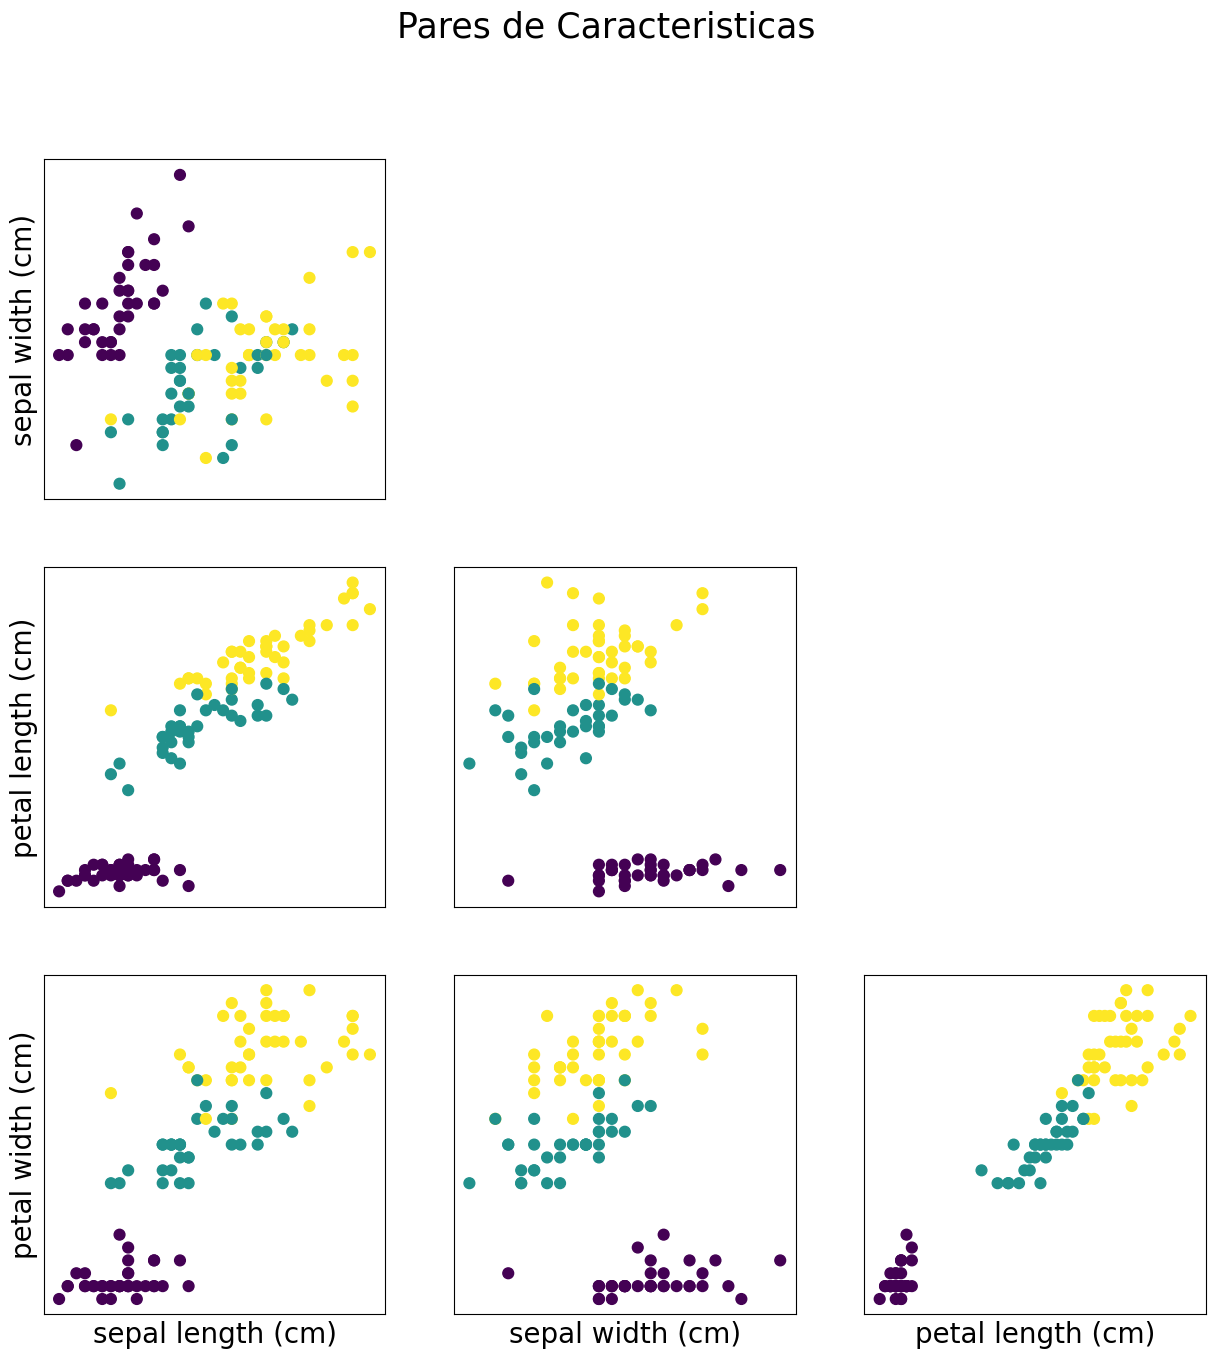

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'],
 random_state=0)
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
plt.suptitle("Pares de Caracteristicas", fontsize=25)
for i in range(3):
  for j in range(3):
    ax[i, j].scatter(X_train[:, j], X_train[:, i + 1], c=y_train, s=60)
    ax[i, j].set_xticks(())
    ax[i, j].set_yticks(())
    if i == 2:
      ax[i, j].set_xlabel(iris['feature_names'][j], fontsize=20)
    if j == 0:
      ax[i, j].set_ylabel(iris['feature_names'][i + 1], fontsize=20)     
    if j > i:
      ax[i, j].set_visible(False)
plt.show()

**Construindo o Modelo Preditivo**
Agora podemos começar a construir um modelo de Aprendizagem de Máquina. Atualmente, existem diversos algoritmos diponíveis na biblioteca scikit-learn que podem ser utilizados para realizar essa classificação. Neste momento, iremos aplicar o algoritmo KNN que é um algoritmo que identificar os K-vizinhos mais próximos utilizando a distância euclidiana da projeção dos dados (teste e treinamento).


In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
#KNN Classifier
knn = KNeighborsClassifier(n_neighbors=1)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'],
 random_state=0)
#Aplying the Trainning Data
knn.fit(X_train, y_train)
#Generating a Test Case
X_data_iris_case = np.array([[5, 2.9, 1, 0.2]])
prediction_case = knn.predict(X_data_iris_case)
print(prediction_case)
print(iris['target_names'][prediction_case])

[0]
['setosa']


Construindo e Avaliando um Classificador KNN

In [12]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
#KNN Classifier
knn = KNeighborsClassifier(n_neighbors=1)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris['data'], iris['target'],
 random_state=0)
#Aplying the Trainning Data
knn.fit(X_train, y_train)
#Predict using the Test Data
y_pred = knn.predict(X_test)
classifier_score = np.mean(y_pred == y_test)
print(classifier_score)

0.9736842105263158
